In [ ]:
import numpy as np
from torchvision.datasets import MNIST, CIFAR10, CIFAR100, STL10
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from diffusers import AutoencoderKL
from scipy.stats import shapiro, normaltest

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
#elif torch.backends.mps.is_available():
#    device = torch.device('mps')
else:
    device = torch.device('cpu')

In [ ]:
torch.manual_seed(1101252)
BATCH_SIZE_IMG = 32

tfm = T.Compose([
    #T.Resize(IMG_SIZE, interpolation=T.InterpolationMode.BICUBIC),
    #T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
])

dataset = CIFAR100(
    root="datasets/cifar100/",
    train=True,
    download=True,
    transform=tfm,
)

data_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE_IMG,
    shuffle=True,
    num_workers=4,
    pin_memory=True if device.type == 'cuda' else False
)

In [ ]:
ae_model = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse") # mse or ema
ae_model = ae_model.to(device).eval()
ae_model.requires_grad_(False)
ae_scaling = ae_model.config.scaling_factor

In [ ]:
latents = []
labels = []
for x, y in tqdm(data_loader):
    x = x.to(device)
    x = 2.0 * x - 1.0  # [0,1] -> [-1,1]
    with torch.no_grad():
        posterior = ae_model.encode(x).latent_dist
        z = posterior.mode() * ae_scaling
        latents.append(z.cpu())
        labels.append(y)
latents = torch.cat(latents, dim=0)
labels = torch.cat(labels, dim=0)

  0%|          | 0/1563 [00:00<?, ?it/s]

In [ ]:
unique_labels, labels_counts = torch.unique(labels, return_counts=True)

In [ ]:
num_samples_per_class = 5
sampled_indices = torch.cat([torch.where(labels == c)[0][:num_samples_per_class] for c in unique_labels])
sampled_labels = labels[sampled_indices]
sampled_latents = latents[sampled_indices]

In [ ]:
gram_latents = torch.cov(sampled_latents.view(sampled_latents.shape[0], -1))
gram_diag = torch.diag(gram_latents)
gram_latents /= torch.sqrt(gram_diag[:,None]*gram_diag[None,:])
sim_matrix = (1+gram_latents)/2
degree_matrix = sim_matrix.sum(dim=1)

In [9]:
def random_walk_pt_from_evs(sim_matrix, times, eps=1e-12, symmetrize=True):
    """
    Continuous-time random walk probabilities using eigenvectors.

    L_rw = I - D^{-1} W

    Parameters
    ----------
    sim_matrix : (N, N) torch.Tensor
        Dense affinity matrix W.

    times : (T,) torch.Tensor
        Times at which to evaluate p_t.

    Returns
    -------
    p_t : (T, N, N)
        p_t[a, i, j] = probability to be at j at times[a],
        starting from site i.

    evals_L : (N,)
        Eigenvalues of L_rw / L_sym, sorted ascending.

    U : (N, N)
        Eigenvectors of S = D^{-1/2} W D^{-1/2}.

    degree : (N,)
        Degree vector.
    """

    W = sim_matrix

    if symmetrize:
        W = 0.5 * (W + W.T)

    N = W.shape[0]

    times = times.to(device=W.device, dtype=W.dtype)

    degree = W.sum(dim=1)
    degree_safe = degree.clamp_min(eps)

    d_sqrt = torch.sqrt(degree_safe)
    d_inv_sqrt = torch.rsqrt(degree_safe)

    # S = D^{-1/2} W D^{-1/2}
    S = d_inv_sqrt[:, None] * W * d_inv_sqrt[None, :]

    # S u_a = mu_a u_a
    evals_S, U = torch.linalg.eigh(S)

    # largest mu_a first <=> smallest Laplacian eigenvalues first
    idx = torch.argsort(evals_S, descending=True)
    evals_S = evals_S[idx]
    U = U[:, idx]

    evals_L = 1.0 - evals_S
    evals_L = evals_L.clamp_min(0.0)

    # exp(-t lambda_a), shape (T, N)
    expfac = torch.exp(-times[:, None] * evals_L[None, :])

    # Right eigenvectors of L_rw:
    # V = D^{-1/2} U
    V = d_inv_sqrt[:, None] * U

    # Inverse basis:
    # V^{-1} = U^T D^{1/2}
    Vinv = U.T * d_sqrt[None, :]

    # exp(-t L_rw) = V exp(-t Λ) V^{-1}
    p_t = torch.einsum("ia,ta,aj->tij", V, expfac, Vinv)

    # numerical cleanup
    p_t = p_t.real
    p_t = p_t.clamp_min(0.0)
    p_t = p_t / p_t.sum(dim=-1, keepdim=True).clamp_min(eps)

    return p_t, evals_L, U, degree

In [10]:
t = torch.logspace(-3, 2, 200)
p_t, evals_L, U, degree = random_walk_pt_from_evs(sim_matrix, t)

In [11]:
from mhn import wfp_gram_uniform_init, wfp_gram_dirichlet_init

In [12]:
#w_t = wfp_gram_uniform_init(1/t, 0.5*gram_latents**2, 5000, verbose=True)

In [ ]:
w_t.shape

In [14]:
w_t = wfp_gram_dirichlet_init(1/t, gram_latents, num_steps=5000, num_runs=200, verbose=True)

100%|██████████| 5000/5000 [18:06<00:00,  4.60it/s]


In [15]:
H_w = -w_t*w_t.log()
H_w[~torch.isfinite(H_w)] = 0
H_w = H_w.sum(dim=-1)
H_w = H_w.mean(dim=0)

In [16]:
H_p = torch.sum(-p_t*p_t.log(), dim=1).mean(dim=1)

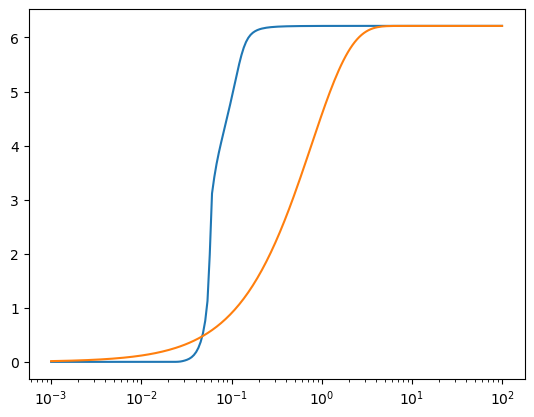

In [17]:
plt.plot(t, H_w)
plt.plot(t, H_p)
plt.xscale('log')

In [ ]:
import torch
import torch.nn.functional as F


def spectral_embedding_dense_torch(
    W,
    laplacian="sym",        # "sym" or "rw"
    row_normalize=False,
    zero_diag=True,
    symmetrize=True,
    eps=1e-12,
):
    """
    Computes the full dense spectral embedding.

    Returns all spectral modes, ordered from low-frequency to high-frequency
    Laplacian modes.
    """

    W = W.clone()

    if symmetrize:
        W = 0.5 * (W + W.T)

    if zero_diag:
        W.fill_diagonal_(0.0)

    d = W.sum(dim=1)
    d_safe = d.clamp_min(eps)

    d_inv_sqrt = torch.rsqrt(d_safe)

    S = d_inv_sqrt[:, None] * W * d_inv_sqrt[None, :]

    evals_all, U_all = torch.linalg.eigh(S)

    # Descending eigenvalues of S = ascending eigenvalues of L
    evals_S = torch.flip(evals_all, dims=[0])
    U = torch.flip(U_all, dims=[1])

    evals_L = 1.0 - evals_S

    if laplacian == "sym":
        Y_full = U
    elif laplacian == "rw":
        Y_full = d_inv_sqrt[:, None] * U
    else:
        raise ValueError("laplacian must be 'sym' or 'rw'")

    if row_normalize:
        Y_full = F.normalize(Y_full, p=2, dim=1, eps=eps)

    return Y_full, evals_S, evals_L

In [ ]:
Y_full, evals_S, evals_L = spectral_embedding_dense_torch(sim_matrix, laplacian="rw", row_normalize=True)

In [ ]:
Y_full[:,:3].T  @ Y_full[:,:3]

In [ ]:
from sklearn.cluster import KMeans
clus_nums = np.arange(2, 300, 3)
entropies = []
for n_clusters in tqdm(clus_nums):
    clust = KMeans(n_clusters=n_clusters, n_init=n_clusters).fit(Y_full.cpu()[:, :n_clusters])
    c_labels = clust.labels_
    _, counts = torch.unique(torch.tensor(c_labels), return_counts=True)
    prob = counts/counts.sum()
    entropies.append(torch.sum(-prob*prob.log()))
entropies = torch.tensor(entropies)

In [ ]:
plt.plot(clus_nums, entropies/np.log(clus_nums))
plt.xscale('log')